# Antimony Paper

In [1]:
import tellurium as te

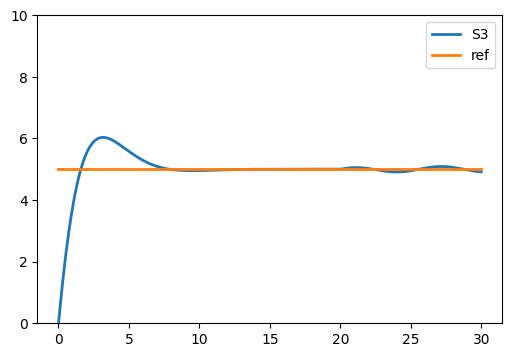

In [61]:
model = """
// Implementation of PID control for a system with a disturbance at time 20

const S1;
S1 -> S2; k1*(S1 + delta*sin(time))
S2 -> S3; k2*S2
S3 -> ; k3*S3
k1 = 1
k2 = 2
k3 = 0.5
ref = 5
delta = 0
$S1 = 5
at time>20: delta = 10

// Proportional controller
kP = 100;
//kP = 0
kI = 50
//kI = 0
kD = 100
//kD = 0
control_error := ref - S3
integral_error = 0
integral_error' = control_error
differential_error := -rateOf(S3)
S1 := kP*control_error + kI*integral_error + kD*differential_error
"""
rr = te.loada(model)
rr.simulate(0, 30, 300, selections=["time", "S3", "ref"])
rr.plot(ylim=[0, 10])